brand, age, mileage, fuel type, and transmission.

# Used Car Price Prediction

## Objective
Build a regression model to predict the selling price of a used car based on features such as brand, car age, mileage, fuel type, transmission, engine size, doors, and owner count.

## Tech Stack
- Python
- pandas
- NumPy
- scikit-learn
- matplotlib
- seaborn
- Jupyter Notebook

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df=pd.read_csv('car_price_dataset.csv')

In [5]:
df.head(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [6]:
df.sample(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
4149,Ford,Focus,2011,1.4,Petrol,Semi-Automatic,94129,4,2,6917
9460,BMW,X5,2003,3.2,Diesel,Automatic,229631,3,1,5107
9260,Kia,Rio,2016,2.5,Petrol,Manual,275604,3,5,5887
8717,Chevrolet,Equinox,2018,4.7,Diesel,Automatic,6212,4,3,15575
6578,Kia,Optima,2016,4.3,Petrol,Automatic,291964,2,4,8860


In [7]:
df.tail(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084
9999,Volkswagen,Tiguan,2001,2.1,Diesel,Manual,157882,3,3,3342


In [8]:
df.shape

(10000, 10)

In [10]:
df.size

100000

In [11]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


### Initial Observation

The dataset contains 10,000 car records and 10 columns. The target variable is `Price`, while the remaining columns contain information about the car's brand, model, year, engine size, fuel type, transmission, mileage, doors, and number of previous owners.

### DATA CLEANING:

In [13]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [14]:
df.isna().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

No missing values were found in the dataset, so no missing-value imputation was required.

In [15]:
df.duplicated().sum()

np.int64(0)

### CHECKING INCONSISTENT CATEGORICAL VALUES:

In [16]:
print(df["Brand"].unique())

<StringArray>
[       'Kia',  'Chevrolet',   'Mercedes',       'Audi', 'Volkswagen',
     'Toyota',      'Honda',        'BMW',    'Hyundai',       'Ford']
Length: 10, dtype: str


In [20]:
print(df["Model"].unique())

<StringArray>
[     'Rio',   'Malibu',      'GLA',       'Q5',     'Golf',    'Camry',
    'Civic', 'Sportage',     'RAV4', '5 Series',     'CR-V',  'Elantra',
   'Tiguan',  'Equinox', 'Explorer',       'A3', '3 Series',   'Tucson',
   'Passat',   'Impala',  'Corolla',   'Optima',   'Fiesta',       'A4',
    'Focus',  'E-Class',   'Sonata',  'C-Class',       'X5',   'Accord']
Length: 30, dtype: str


In [21]:
print(df["Fuel_Type"].unique())

<StringArray>
['Diesel', 'Hybrid', 'Electric', 'Petrol']
Length: 4, dtype: str


In [22]:
print(df["Transmission"].unique())

<StringArray>
['Manual', 'Automatic', 'Semi-Automatic']
Length: 3, dtype: str


### FEATURE ENGINEERING:

In [23]:
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

In [24]:
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2020,6
1,2012,14
2,2020,6
3,2023,3
4,2003,23


Since we require age of the car, we are using this formula(car_age=current year- manufacturing year)

### Brand Feature

The dataset already contains a separate `Brand` column, so brand extraction from a combined car-name column is not required. The existing `Brand` feature is used directly.

In [26]:
df['Car_Age'].describe()


count    10000.000000
mean        14.456300
std          6.897699
min          3.000000
25%          9.000000
50%         14.000000
75%         20.000000
max         26.000000
Name: Car_Age, dtype: float64

In [27]:
df['Car_Age'].min()


np.int64(3)

In [28]:
df['Car_Age'].max()

np.int64(26)

In [29]:
df[df["Car_Age"] < 0]

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price,Car_Age


### EDA:

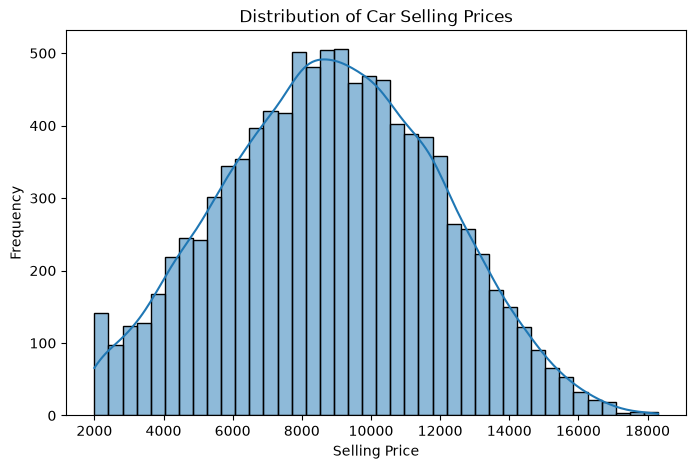

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

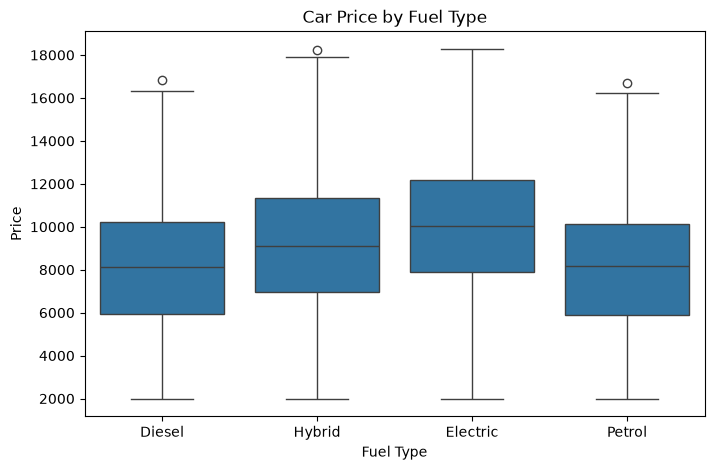

In [31]:
### PRICE VS FUELTYPE:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Price"
)

plt.title("Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")

plt.show()

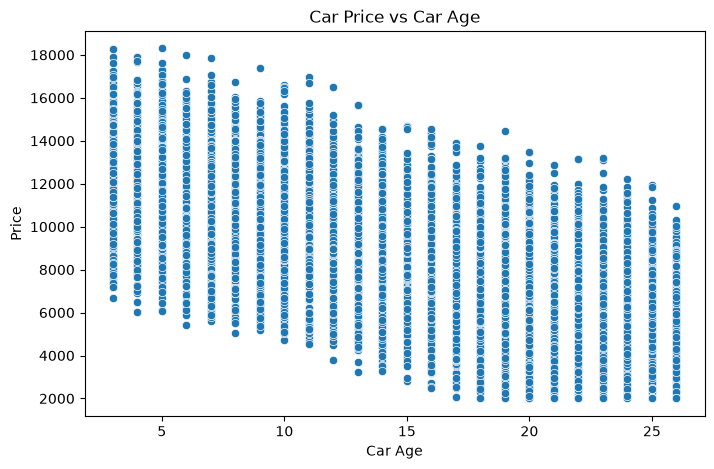

In [32]:
### PRICE Vs CAR AGE:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Price"
)

plt.title("Car Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Price")

plt.show()

The scatter plot shows a negative relationship between car age and selling price. As the age of the car increases, its selling price generally decreases. However, there is considerable variation in price for cars of the same age, indicating that other factors such as brand, mileage, engine size, fuel type, and transmission also influence the selling price."

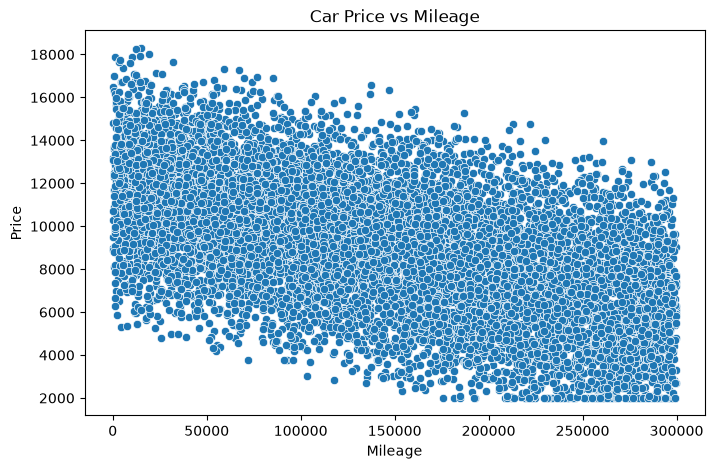

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Mileage",
    y="Price"
)

plt.title("Car Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.show()

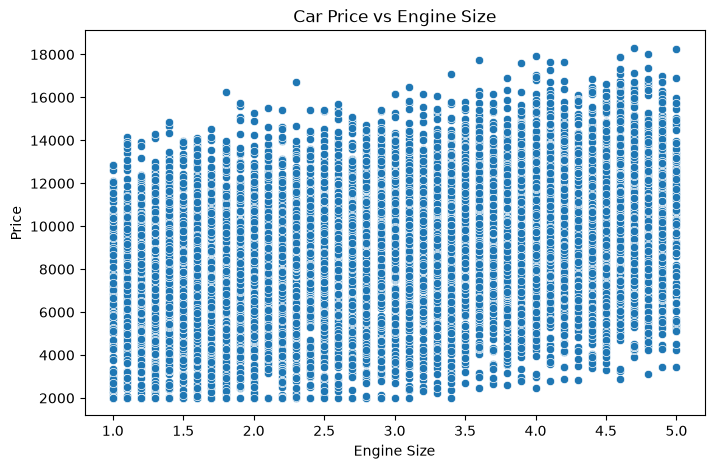

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Engine_Size",
    y="Price"
)

plt.title("Car Price vs Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()

### CORRELATION HEATMAP:

In [41]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

In [42]:
correlation = df[numeric_columns].corr()

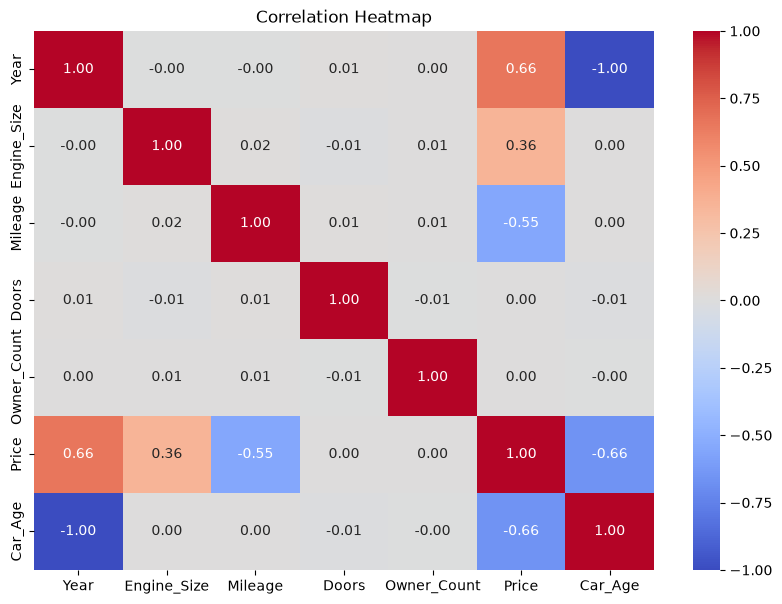

In [43]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### PREAPRING X and y:

In [44]:
y=df['Price']

In [45]:
X=df.drop('Price',axis=1)

In [46]:
X=X.drop('Year',axis=1)

In [47]:
X.head()

,Brand,Model,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Car_Age
0,Kia,Rio,4.2,Diesel,Manual,289944,3,5,6
1,Chevrolet,Malibu,2.0,Hybrid,Automatic,5356,2,3,14
2,Mercedes,GLA,4.2,Diesel,Automatic,231440,4,2,6
3,Audi,Q5,2.0,Electric,Manual,160971,2,1,3
4,Volkswagen,Golf,2.6,Hybrid,Semi-Automatic,286618,3,3,23


In [48]:
categorical_features = [
    "Brand",
    "Model",
    "Fuel_Type",
    "Transmission"
]

In [49]:
numerical_features = [
    "Engine_Size",
    "Mileage",
    "Doors",
    "Owner_Count",
    "Car_Age"
]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 9)
Testing data: (2000, 9)


In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

### LINEAR REGRESSION:

In [53]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [54]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Brand','Model','Engine_Size',...,'Doors','Owner_Count','Car_Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

In [55]:
linear_predictions = linear_model.predict(X_test)

In [56]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

In [57]:
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

In [58]:
linear_r2 = r2_score(
    y_test,
    linear_predictions
)

In [59]:
print("Linear Regression")
print("----------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
----------------------
MAE : 185.60936790877912
RMSE: 233.43452849885108
R²  : 0.9940691341972705


### RANDOM FOREST:

In [60]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [61]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Brand','Model','Engine_Size',...,'Doors','Owner_Count','Car_Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

In [62]:
rf_predictions = rf_model.predict(X_test)

In [63]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

In [64]:
print("Random Forest Regressor")
print("----------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regressor
----------------------
MAE : 255.3068075
RMSE: 328.4660538443242
R²  : 0.9882572749306893


In [65]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,185.609368,233.434528,0.994069
1,Random Forest,255.306807,328.466054,0.988257


### FEATURE IMPORTANCE:

In [66]:
rf_preprocessor = rf_model.named_steps["preprocessor"]

In [67]:
rf_regressor = rf_model.named_steps["model"]

In [68]:
encoded_features = (
    rf_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

In [69]:
all_features = np.concatenate([
    encoded_features,
    numerical_features
])

In [70]:
importances = rf_regressor.feature_importances_

In [71]:
feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
})

In [72]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [73]:
feature_importance.head(15)

,Feature,Importance
51,Car_Age,0.438267
48,Mileage,0.311085
47,Engine_Size,0.134878
41,Fuel_Type_Electric,0.049288
44,Transmission_Automatic,0.045988
42,Fuel_Type_Hybrid,0.009198
50,Owner_Count,0.001448
49,Doors,0.001260
43,Fuel_Type_Petrol,0.001018
40,Fuel_Type_Diesel,0.001007


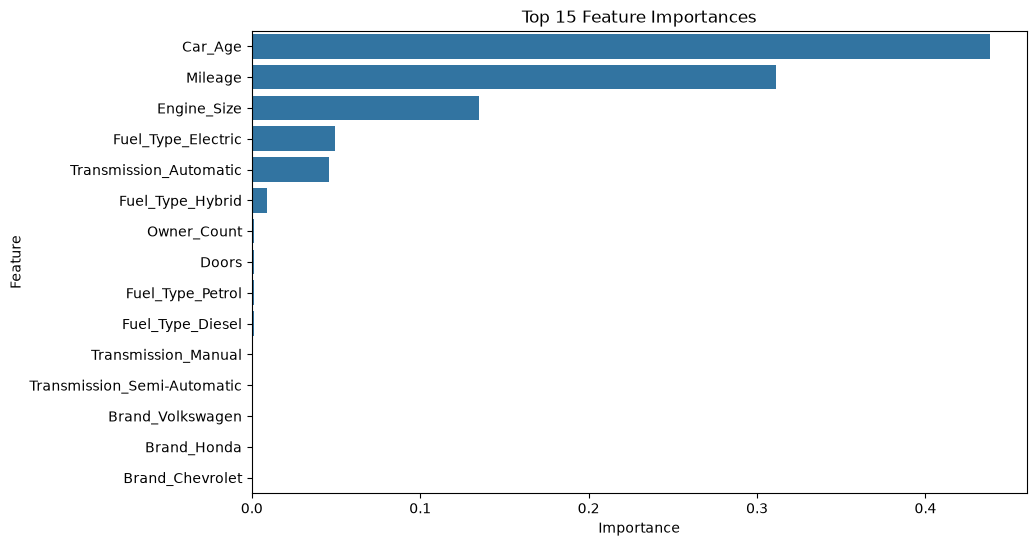

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

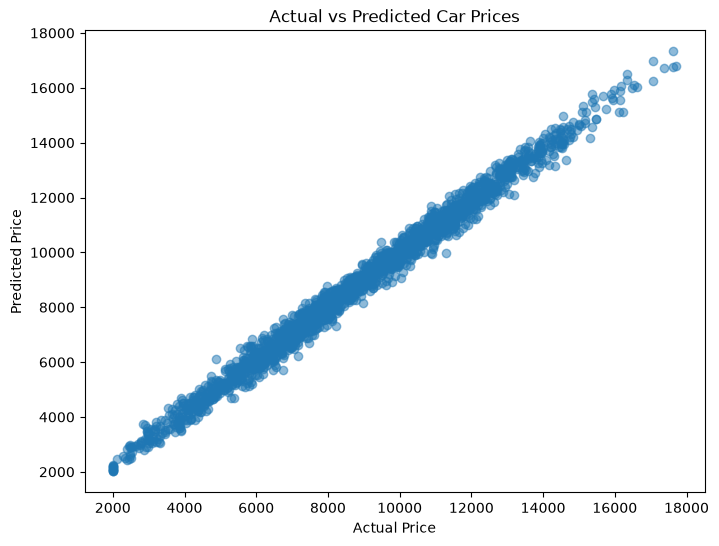

In [75]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

In [76]:
new_car = pd.DataFrame({
    "Brand": ["Toyota"],
    "Model": ["Corolla"],
    "Engine_Size": [2.0],
    "Fuel_Type": ["Petrol"],
    "Transmission": ["Automatic"],
    "Mileage": [50000],
    "Doors": [4],
    "Owner_Count": [2],
    "Car_Age": [5]
})

In [77]:
predicted_price = rf_model.predict(new_car)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 12836.575
